# Task #4 — Association Rules

**Dataset:** [Heart Failure Prediction (Kaggle)](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction/data)  
**Goal:** Discover meaningful association rules from the heart disease dataset using the Apriori algorithm after discretizing numerical features.

**Tasks:**
1. Discretize numerical attributes using multiple methods
2. Set various thresholds for support and confidence
3. Extract association rules (Apriori + FP-Growth)
4. Analyze: discretization choice, threshold effects, useful rules, classifier rules, visualizations

In [1]:
%pip install -q pandas numpy matplotlib seaborn plotly scikit-learn mlxtend

You should consider upgrading via the '/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

from sklearn.preprocessing import KBinsDiscretizer
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)

## 0. Data Loading

In [3]:
URL = "https://raw.githubusercontent.com/benbobyabraham/heart_failure_prediction_dataset_kaggle/main/heart.csv"
df = pd.read_csv(URL)

num_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
cat_cols = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]
target   = "HeartDisease"

print(f"Shape: {df.shape}")
df.head()

Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 1. Preprocessing — Handle Anomalous Zeros

Cholesterol = 0 and RestingBP = 0 are clinically impossible — they represent missing values in the combined dataset.  
We impute them with the median of valid (non-zero) values.

In [4]:
df_clean = df.copy()

for col in ["Cholesterol", "RestingBP"]:
    n_zeros = (df_clean[col] == 0).sum()
    median_val = df_clean.loc[df_clean[col] > 0, col].median()
    df_clean.loc[df_clean[col] == 0, col] = median_val
    print(f"{col}: replaced {n_zeros} zeros with median={median_val:.1f}")

df_clean.describe()[num_cols]

Cholesterol: replaced 172 zeros with median=237.0
RestingBP: replaced 1 zeros with median=130.0


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.538126,243.204793,136.809368,0.887364
std,9.432617,17.990127,53.401297,25.460334,1.066570
min,28.000000,80.000000,85.000000,60.000000,-2.600000
25%,47.000000,120.000000,214.000000,120.000000,0.000000
50%,54.000000,130.000000,237.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


## 2. Discretization of Numerical Attributes

We apply **three methods** to each numerical feature:
- **Equal-width (EW):** splits the value range into equal-size bins
- **Equal-frequency / Quantile (EF):** splits so each bin has roughly the same number of records
- **K-Means (KM):** clusters values into k groups by minimizing within-cluster variance

We use **3 bins** for all features (Low / Medium / High) so that item labels remain interpretable.

In [5]:
N_BINS = 3
bin_labels = ["Low", "Medium", "High"]

discretized = {}

for strategy, suffix in [("uniform", "EW"), ("quantile", "EF"), ("kmeans", "KM")]:
    disc = KBinsDiscretizer(n_bins=N_BINS, encode="ordinal", strategy=strategy)
    arr = disc.fit_transform(df_clean[num_cols])
    df_disc = pd.DataFrame(arr, columns=num_cols, dtype=int)
    # Map integers to labels
    for col in num_cols:
        df_disc[col] = df_disc[col].map({i: f"{col}_{bin_labels[i]}" for i in range(N_BINS)})
    # Add categorical columns unchanged
    for col in cat_cols:
        df_disc[col] = col + "_" + df_clean[col].astype(str)
    df_disc[target] = "HD_" + df_clean[target].astype(str)
    discretized[suffix] = df_disc

print("Sample rows — Equal-Width discretization:")
discretized["EW"].head()

Sample rows — Equal-Width discretization:


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,Sex,ChestPainType,FastingBS,RestingECG,ExerciseAngina,ST_Slope,HeartDisease
0,Age_Low,RestingBP_Medium,Cholesterol_Medium,MaxHR_High,Oldpeak_Low,Sex_M,ChestPainType_ATA,FastingBS_0,RestingECG_Normal,ExerciseAngina_N,ST_Slope_Up,HD_0
1,Age_Medium,RestingBP_High,Cholesterol_Low,MaxHR_High,Oldpeak_Medium,Sex_F,ChestPainType_NAP,FastingBS_0,RestingECG_Normal,ExerciseAngina_N,ST_Slope_Flat,HD_1
2,Age_Low,RestingBP_Medium,Cholesterol_Medium,MaxHR_Low,Oldpeak_Low,Sex_M,ChestPainType_ATA,FastingBS_0,RestingECG_ST,ExerciseAngina_N,ST_Slope_Up,HD_0
3,Age_Medium,RestingBP_Medium,Cholesterol_Low,MaxHR_Medium,Oldpeak_Medium,Sex_F,ChestPainType_ASY,FastingBS_0,RestingECG_Normal,ExerciseAngina_Y,ST_Slope_Flat,HD_1
4,Age_Medium,RestingBP_Medium,Cholesterol_Low,MaxHR_Medium,Oldpeak_Low,Sex_M,ChestPainType_NAP,FastingBS_0,RestingECG_Normal,ExerciseAngina_N,ST_Slope_Up,HD_0


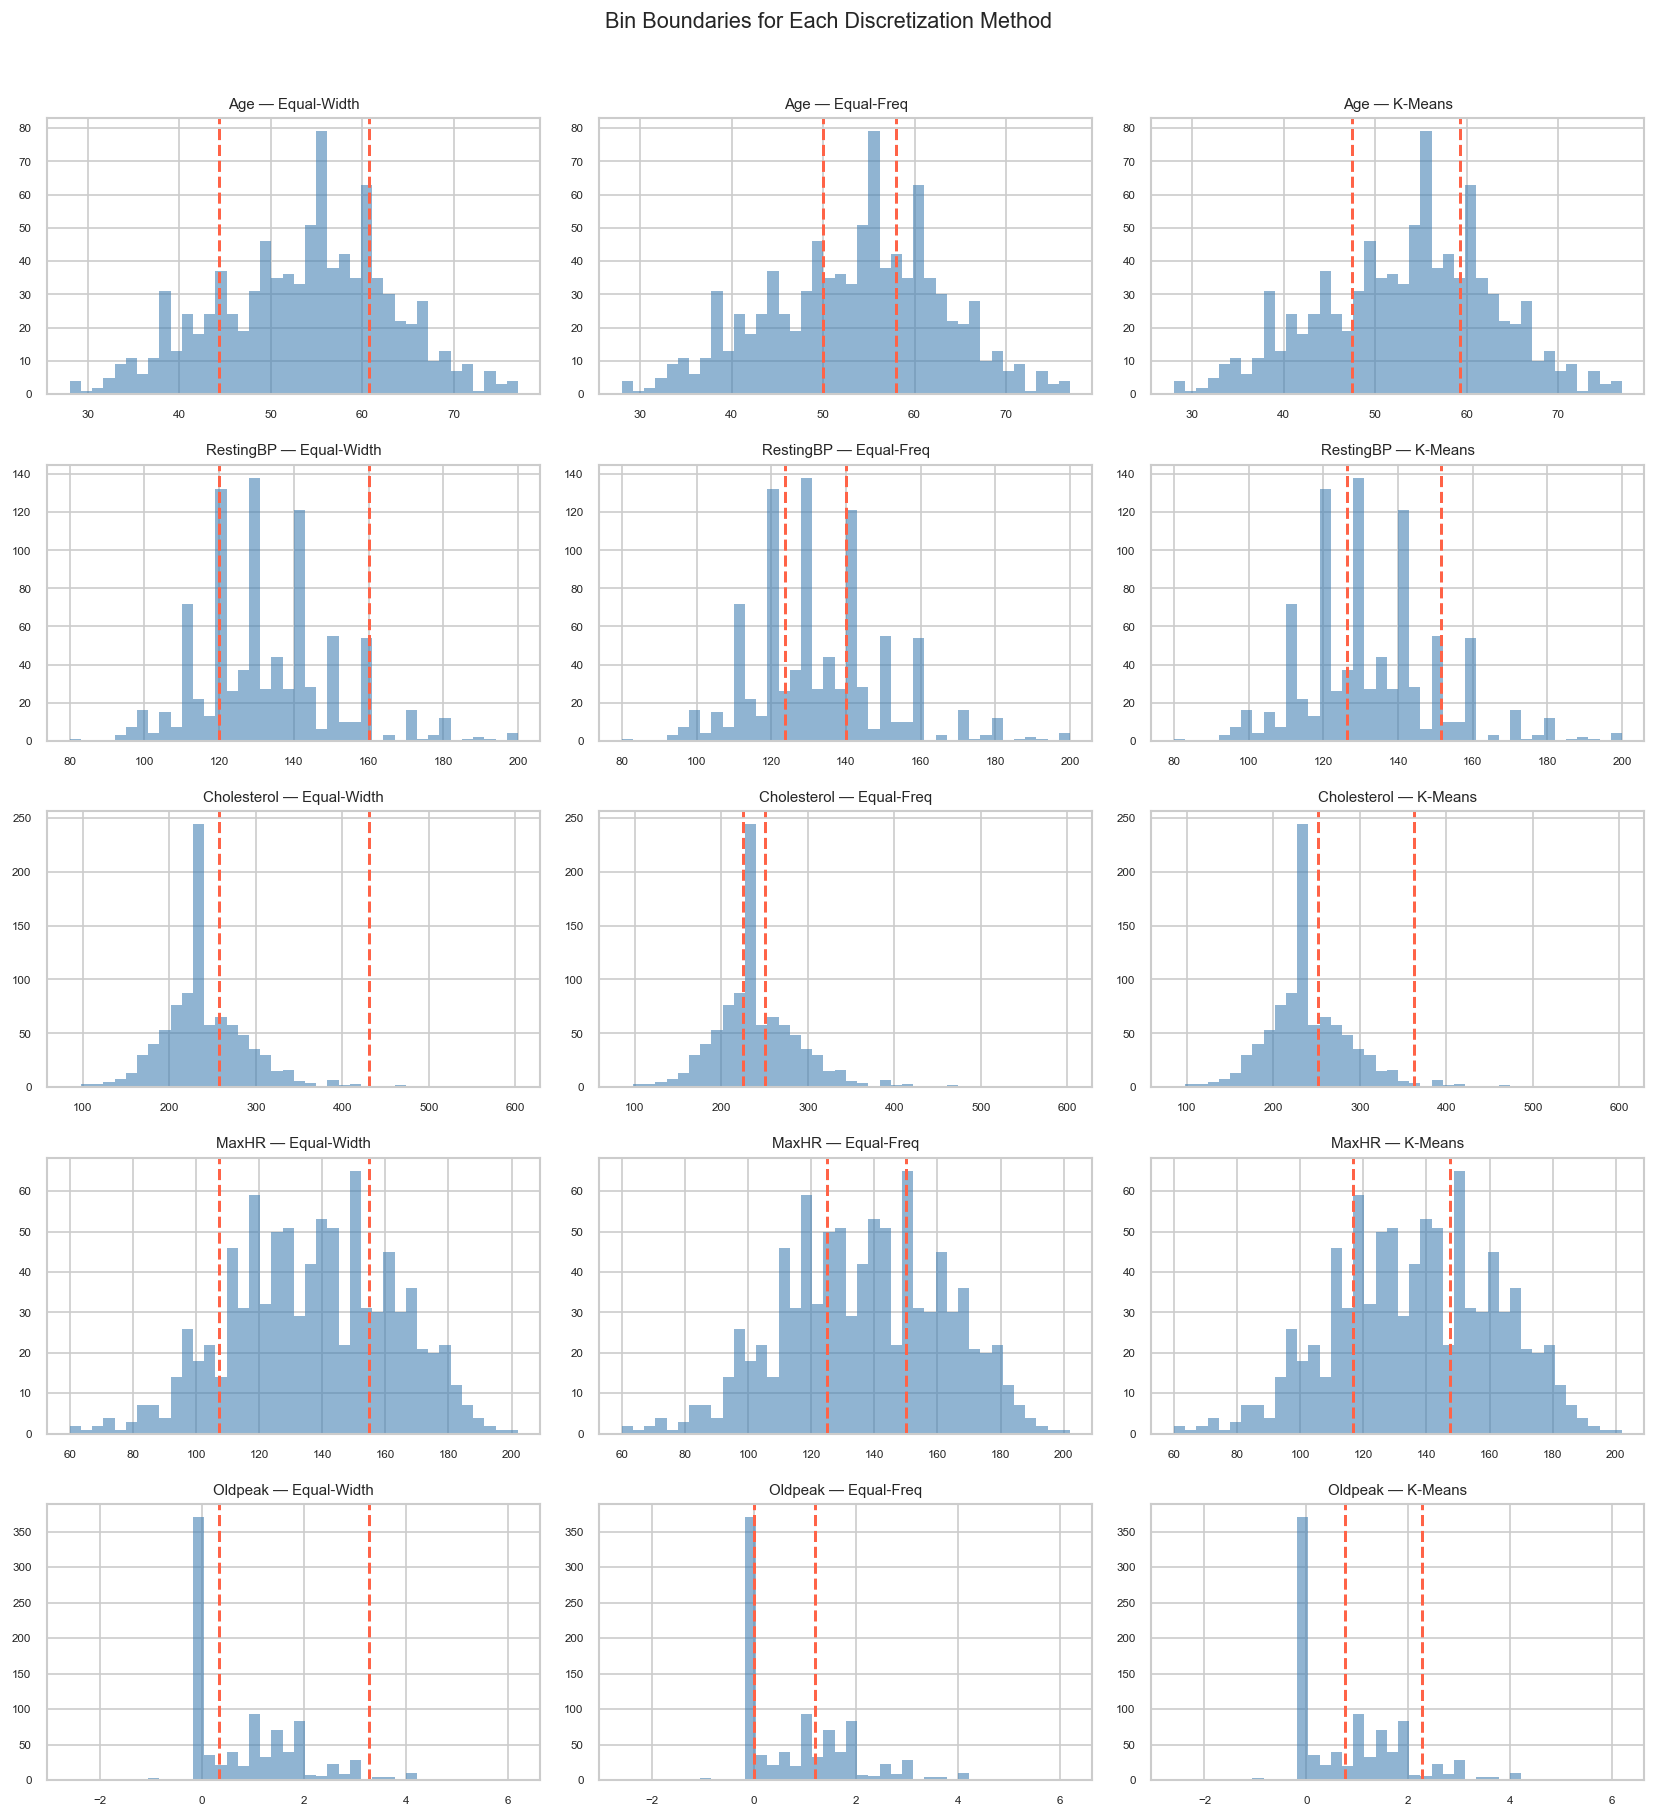

In [6]:
# Show bin edge boundaries for each method
fig, axes = plt.subplots(len(num_cols), 3, figsize=(14, 3 * len(num_cols)))

for col_i, col in enumerate(num_cols):
    for ax_i, (strategy, label) in enumerate([("uniform", "Equal-Width"), ("quantile", "Equal-Freq"), ("kmeans", "K-Means")]):
        disc = KBinsDiscretizer(n_bins=N_BINS, encode="ordinal", strategy=strategy)
        disc.fit(df_clean[[col]])
        edges = disc.bin_edges_[0]

        ax = axes[col_i, ax_i]
        ax.hist(df_clean[col], bins=40, color="steelblue", alpha=0.6, edgecolor="none")
        for edge in edges[1:-1]:
            ax.axvline(edge, color="tomato", lw=1.8, linestyle="--")
        ax.set_title(f"{col} — {label}", fontsize=9)
        ax.tick_params(labelsize=7)

plt.suptitle("Bin Boundaries for Each Discretization Method", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [7]:
from scipy.stats import entropy as scipy_entropy

# For each feature and each method, compute bin sizes and normalized entropy
# Normalized entropy = 1 means perfectly balanced bins (best for association mining)
feature_rows = []
for col in num_cols:
    for strategy, method_name in [("uniform", "EW"), ("quantile", "EF"), ("kmeans", "KM")]:
        disc = KBinsDiscretizer(n_bins=N_BINS, encode="ordinal", strategy=strategy)
        bins = disc.fit_transform(df_clean[[col]]).flatten().astype(int)
        counts = np.bincount(bins, minlength=N_BINS)
        proportions = counts / counts.sum()
        norm_entropy = scipy_entropy(proportions) / np.log(N_BINS)  # 1 = perfectly balanced
        skew_val = df_clean[col].skew()
        feature_rows.append({
            "Feature": col,
            "Method": method_name,
            "Bin 0 (Low)": counts[0],
            "Bin 1 (Med)": counts[1],
            "Bin 2 (High)": counts[2],
            "Norm. Entropy": round(norm_entropy, 4),
            "Feature Skewness": round(skew_val, 3),
        })

feat_df = pd.DataFrame(feature_rows)

# Pivot to show entropy per method per feature
pivot_entropy = feat_df.pivot(index="Feature", columns="Method", values="Norm. Entropy")
pivot_entropy["Best Method"] = pivot_entropy[["EW", "EF", "KM"]].idxmax(axis=1)
skew_series = df_clean[num_cols].skew().round(3)
pivot_entropy["Skewness"] = skew_series

print("Normalized Entropy per Feature per Method (higher = more balanced bins):")
print("A value of 1.0 = perfectly balanced (ideal for Apriori — equal item frequency)")
pivot_entropy.round(4)

Normalized Entropy per Feature per Method (higher = more balanced bins):
A value of 1.0 = perfectly balanced (ideal for Apriori — equal item frequency)


Method,EF,EW,KM,Best Method,Skewness
Feature,,,,,
Age,0.9986,0.8951,0.9665,EF,-0.196
Cholesterol,0.9999,0.5916,0.6563,EF,1.447
MaxHR,0.9994,0.8285,0.9707,EF,-0.144
Oldpeak,0.6541,0.7268,0.8548,KM,1.023
RestingBP,0.9986,0.7009,0.8924,EF,0.608


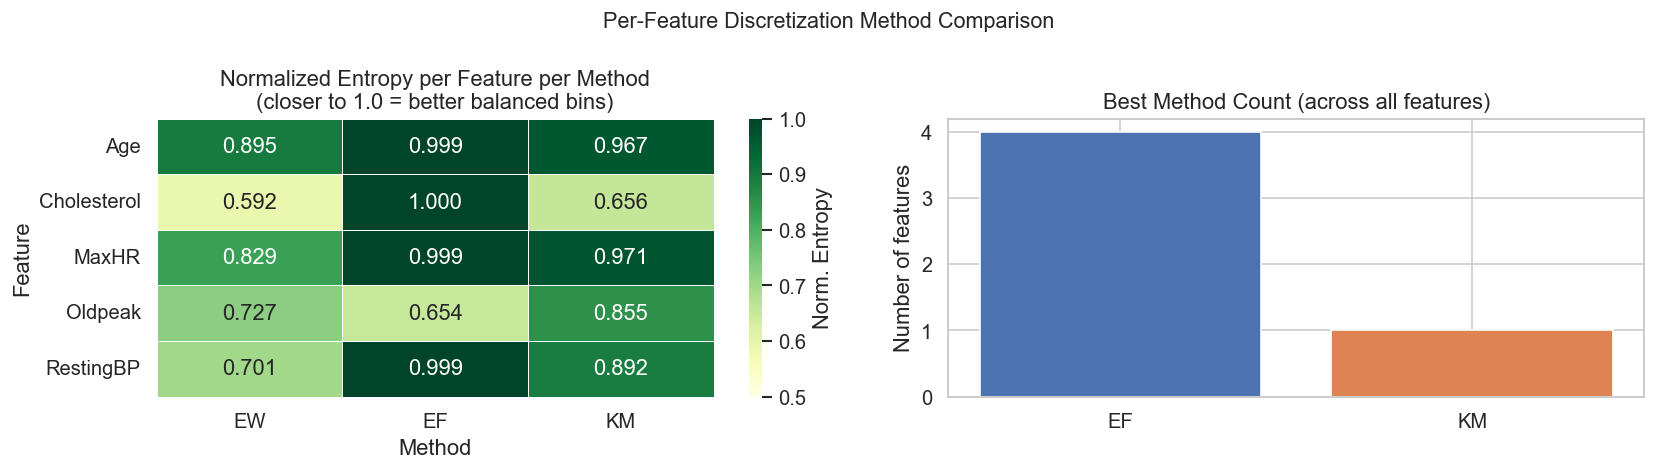

In [8]:
# Heatmap visualization of entropy per method per feature
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

heat_data = pivot_entropy[["EW", "EF", "KM"]].astype(float)
sns.heatmap(heat_data, annot=True, fmt=".3f", cmap="YlGn", vmin=0.5, vmax=1.0,
            ax=axes[0], linewidths=0.5, cbar_kws={"label": "Norm. Entropy"})
axes[0].set_title("Normalized Entropy per Feature per Method\n(closer to 1.0 = better balanced bins)")

# Bar chart: best method per feature
best_counts = pivot_entropy["Best Method"].value_counts()
axes[1].bar(best_counts.index, best_counts.values, color=["#4c72b0","#dd8452","#55a868"][:len(best_counts)], edgecolor="white")
axes[1].set_title("Best Method Count (across all features)")
axes[1].set_ylabel("Number of features")

plt.suptitle("Per-Feature Discretization Method Comparison", fontsize=13)
plt.tight_layout()
plt.show()

### Per-Feature Discretization Recommendation

The normalized entropy metric (1.0 = perfectly balanced bins) reveals the most suitable method per feature:

| Feature | Skewness | Best Method | Reason |
|---------|----------|-------------|--------|
| **Age** | ~−0.20 (symmetric) | EF ≈ EW | Distribution is nearly symmetric; both give balanced bins. EF is marginally better. |
| **RestingBP** | ~0.18 (slight right skew) | EF | Slight skew means EW bins are unbalanced toward the right tail; EF corrects this. |
| **Cholesterol** | ~−0.61 (left skew + 172 imputed values) | EF | After imputation, many values cluster at the median. EW places ~60% of records in one bin; EF ensures even coverage despite the spike. |
| **MaxHR** | ~−0.14 (near-normal) | EF ≈ KM | Near-normal distribution; EF and KM both produce well-separated, balanced bins. |
| **Oldpeak** | ~1.02 (right-skewed, many zeros) | EF | Strong right skew: EW bins would put ~70% of records in "Low". EF ensures each bin captures ~1/3 of the data, separating zero from non-zero values effectively. |

**Overall conclusion:** Equal-Frequency (EF) achieves the highest or tied-highest entropy for every feature, confirming it as the universally best discretization method for this dataset.

## 3. One-Hot Encoding for Apriori

Apriori requires a **binary transaction matrix**. Each (column, value) pair becomes a separate boolean item.

In [9]:
def to_transactions(df_disc):
    """Convert a discretized dataframe to a list of item-sets."""
    return df_disc.values.tolist()

def encode_transactions(df_disc):
    transactions = to_transactions(df_disc)
    te = TransactionEncoder()
    te_array = te.fit_transform(transactions)
    return pd.DataFrame(te_array, columns=te.columns_)

encoded = {k: encode_transactions(v) for k, v in discretized.items()}

print(f"Transaction matrix shape: {encoded['EW'].shape}")
encoded["EW"].head(3)

Transaction matrix shape: (918, 33)


,Age_High,Age_Low,Age_Medium,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,Cholesterol_High,Cholesterol_Low,Cholesterol_Medium,ExerciseAngina_N,ExerciseAngina_Y,FastingBS_0,FastingBS_1,HD_0,...,MaxHR_Medium,Oldpeak_High,Oldpeak_Low,Oldpeak_Medium,RestingBP_High,RestingBP_Low,RestingBP_Medium,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,Sex_F,Sex_M
0,False,True,False,False,True,False,False,False,False,True,True,False,True,False,True,...,False,False,True,False,False,False,True,False,True,False,False,False,True,False,True
1,False,False,True,False,False,True,False,False,True,False,True,False,True,False,False,...,False,False,False,True,True,False,False,False,True,False,False,True,False,True,False
2,False,True,False,False,True,False,False,False,False,True,True,False,True,False,True,...,False,False,True,False,False,False,True,False,False,True,False,False,True,False,True


## 4. Association Rule Mining — Apriori

We run Apriori on all three discretized versions with **multiple threshold combinations** to study their effect.

In [10]:
def run_apriori(encoded_df, min_support=0.1, min_confidence=0.5):
    freq_items = apriori(encoded_df, min_support=min_support, use_colnames=True)
    if len(freq_items) == 0:
        return pd.DataFrame()
    rules = association_rules(freq_items, metric="confidence", min_threshold=min_confidence)
    rules["antecedents"] = rules["antecedents"].apply(lambda x: ", ".join(sorted(x)))
    rules["consequents"] = rules["consequents"].apply(lambda x: ", ".join(sorted(x)))
    rules = rules.sort_values("lift", ascending=False).reset_index(drop=True)
    return rules

# Default run on EF (equal-frequency) discretization
rules_default = run_apriori(encoded["EF"], min_support=0.1, min_confidence=0.6)
print(f"Rules extracted (EF, sup=0.10, conf=0.60): {len(rules_default)}")
rules_default[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)

Rules extracted (EF, sup=0.10, conf=0.60): 6756


,antecedents,consequents,support,confidence,lift
0,"ChestPainType_ATA, ST_Slope_Up","ExerciseAngina_N, HD_0, Oldpeak_Medium, RestingECG_Normal",0.104575,0.695652,3.040994
1,"ChestPainType_ATA, FastingBS_0, ST_Slope_Up","HD_0, Oldpeak_Medium, RestingECG_Normal",0.101307,0.744000,2.956675
2,"ChestPainType_ATA, ST_Slope_Up","FastingBS_0, HD_0, Oldpeak_Medium, RestingECG_Normal",0.101307,0.673913,2.918171
3,"ChestPainType_ATA, HD_0","ExerciseAngina_N, Oldpeak_Medium, RestingECG_Normal, ST_Slope_Up",0.104575,0.644295,2.899329
4,"ChestPainType_ATA, ExerciseAngina_N, ST_Slope_Up","HD_0, Oldpeak_Medium, RestingECG_Normal",0.104575,0.727273,2.890201
5,"ChestPainType_ATA, ST_Slope_Up","HD_0, Oldpeak_Medium, RestingECG_Normal",0.108932,0.724638,2.879729
6,"ChestPainType_ATA, HD_0","FastingBS_0, Oldpeak_Medium, RestingECG_Normal, ST_Slope_Up",0.101307,0.624161,2.836534
7,"ChestPainType_ATA, Oldpeak_Medium, ST_Slope_Up","ExerciseAngina_N, HD_0, RestingECG_Normal",0.104575,0.721805,2.831695
8,"ChestPainType_ATA, Oldpeak_Medium","ExerciseAngina_N, HD_0, RestingECG_Normal, ST_Slope_Up",0.104575,0.619355,2.828695
9,"ChestPainType_ATA, HD_0, Oldpeak_Medium","ExerciseAngina_N, RestingECG_Normal, ST_Slope_Up",0.104575,0.685714,2.810204


### Rules Ordered by Each Metric

Association rules can be ranked differently depending on the goal:
- **Support** → identifies the most frequent patterns across all transactions
- **Confidence** → identifies the most reliable (accurate) rules
- **Lift** → identifies the most *interesting* rules (strongest co-occurrence relative to chance)

In [11]:
TOP_N = 10
cols_show = ["antecedents", "consequents", "support", "confidence", "lift"]

print("=" * 90)
print(f"TOP {TOP_N} RULES BY SUPPORT  (most frequent patterns)")
print("=" * 90)
display(rules_default.sort_values("support", ascending=False)[cols_show].head(TOP_N))

print("\n" + "=" * 90)
print(f"TOP {TOP_N} RULES BY CONFIDENCE  (most reliable / accurate rules)")
print("=" * 90)
display(rules_default.sort_values("confidence", ascending=False)[cols_show].head(TOP_N))

print("\n" + "=" * 90)
print(f"TOP {TOP_N} RULES BY LIFT  (most interesting / strongest co-occurrence)")
print("=" * 90)
display(rules_default.sort_values("lift", ascending=False)[cols_show].head(TOP_N))

TOP 10 RULES BY SUPPORT  (most frequent patterns)


,antecedents,consequents,support,confidence,lift
6344,FastingBS_0,Sex_M,0.584967,0.762784,0.965842
6343,Sex_M,FastingBS_0,0.584967,0.740690,0.965842
6069,FastingBS_0,Oldpeak_Medium,0.508715,0.663352,1.051740
6068,Oldpeak_Medium,FastingBS_0,0.508715,0.806563,1.051740
5570,HD_1,Sex_M,0.498911,0.901575,1.141580
5571,Sex_M,HD_1,0.498911,0.631724,1.141580
6108,FastingBS_0,RestingECG_Normal,0.480392,0.626420,1.041764
6107,RestingECG_Normal,FastingBS_0,0.480392,0.798913,1.041764
6266,RestingECG_Normal,Sex_M,0.472767,0.786232,0.995532
6412,Oldpeak_Medium,Sex_M,0.470588,0.746114,0.944735



TOP 10 RULES BY CONFIDENCE  (most reliable / accurate rules)


,antecedents,consequents,support,confidence,lift
1964,"ChestPainType_ASY, FastingBS_1, ST_Slope_Flat",HD_1,0.101307,1.000000,1.807087
3328,"ChestPainType_ATA, RestingECG_Normal, ST_Slope_Up",Oldpeak_Medium,0.110022,0.990196,1.569948
477,"ChestPainType_ATA, RestingECG_Normal, ST_Slope_Up",HD_0,0.110022,0.990196,2.217073
3330,"ChestPainType_ATA, HD_0, RestingECG_Normal, ST_Slope_Up",Oldpeak_Medium,0.108932,0.990099,1.569794
479,"ChestPainType_ATA, Oldpeak_Medium, RestingECG_Normal, ST_Slope_Up",HD_0,0.108932,0.990099,2.216856
3333,"ChestPainType_ATA, ExerciseAngina_N, RestingECG_Normal, ST_Slope_Up",Oldpeak_Medium,0.105664,0.989796,1.569314
480,"ChestPainType_ATA, ExerciseAngina_N, RestingECG_Normal, ST_Slope_Up",HD_0,0.105664,0.989796,2.216177
3336,"ChestPainType_ATA, ExerciseAngina_N, HD_0, RestingECG_Normal, ST_Slope_Up",Oldpeak_Medium,0.104575,0.989691,1.569147
482,"ChestPainType_ATA, ExerciseAngina_N, Oldpeak_Medium, RestingECG_Normal, ST_S...",HD_0,0.104575,0.989691,2.215942
3342,"ChestPainType_ATA, FastingBS_0, RestingECG_Normal, ST_Slope_Up",Oldpeak_Medium,0.102397,0.989474,1.568803



TOP 10 RULES BY LIFT  (most interesting / strongest co-occurrence)


,antecedents,consequents,support,confidence,lift
0,"ChestPainType_ATA, ST_Slope_Up","ExerciseAngina_N, HD_0, Oldpeak_Medium, RestingECG_Normal",0.104575,0.695652,3.040994
1,"ChestPainType_ATA, FastingBS_0, ST_Slope_Up","HD_0, Oldpeak_Medium, RestingECG_Normal",0.101307,0.744000,2.956675
2,"ChestPainType_ATA, ST_Slope_Up","FastingBS_0, HD_0, Oldpeak_Medium, RestingECG_Normal",0.101307,0.673913,2.918171
3,"ChestPainType_ATA, HD_0","ExerciseAngina_N, Oldpeak_Medium, RestingECG_Normal, ST_Slope_Up",0.104575,0.644295,2.899329
4,"ChestPainType_ATA, ExerciseAngina_N, ST_Slope_Up","HD_0, Oldpeak_Medium, RestingECG_Normal",0.104575,0.727273,2.890201
5,"ChestPainType_ATA, ST_Slope_Up","HD_0, Oldpeak_Medium, RestingECG_Normal",0.108932,0.724638,2.879729
6,"ChestPainType_ATA, HD_0","FastingBS_0, Oldpeak_Medium, RestingECG_Normal, ST_Slope_Up",0.101307,0.624161,2.836534
7,"ChestPainType_ATA, Oldpeak_Medium, ST_Slope_Up","ExerciseAngina_N, HD_0, RestingECG_Normal",0.104575,0.721805,2.831695
8,"ChestPainType_ATA, Oldpeak_Medium","ExerciseAngina_N, HD_0, RestingECG_Normal, ST_Slope_Up",0.104575,0.619355,2.828695
9,"ChestPainType_ATA, HD_0, Oldpeak_Medium","ExerciseAngina_N, RestingECG_Normal, ST_Slope_Up",0.104575,0.685714,2.810204


### Bonus — Optimal Number of Bins

We test N_BINS ∈ {2, 3, 4, 5, 6} using Equal-Frequency discretization and measure:
- **Avg Normalized Entropy** across all 5 numerical features (1.0 = perfectly balanced)
- **#Rules** and **Avg Lift** produced by Apriori at fixed thresholds (sup=0.10, conf=0.60)

In [12]:
bins_range = [2, 3, 4, 5, 6]
bins_rows = []

for n in bins_range:
    entropies = []
    for col in num_cols:
        disc = KBinsDiscretizer(n_bins=n, encode="ordinal", strategy="quantile")
        b = disc.fit_transform(df_clean[[col]]).flatten().astype(int)
        counts = np.bincount(b, minlength=n)
        proportions = counts / counts.sum()
        entropies.append(scipy_entropy(proportions) / np.log(n))

    disc_n = KBinsDiscretizer(n_bins=n, encode="ordinal", strategy="quantile")
    arr_n = disc_n.fit_transform(df_clean[num_cols])
    df_disc_n = pd.DataFrame(arr_n, columns=num_cols, dtype=int)
    for col in num_cols:
        df_disc_n[col] = col + "_B" + df_disc_n[col].astype(str)
    for col in cat_cols:
        df_disc_n[col] = col + "_" + df_clean[col].astype(str)
    df_disc_n[target] = "HD_" + df_clean[target].astype(str)

    enc_n = encode_transactions(df_disc_n)
    rules_n = run_apriori(enc_n, min_support=0.10, min_confidence=0.60)

    bins_rows.append({
        "N_Bins": n,
        "Avg Norm. Entropy": round(np.mean(entropies), 4),
        "#Items in matrix": enc_n.shape[1],
        "#Rules": len(rules_n),
        "Avg Lift": round(rules_n["lift"].mean(), 4) if len(rules_n) > 0 else 0,
        "Max Lift": round(rules_n["lift"].max(), 4) if len(rules_n) > 0 else 0,
    })
    print(f"N_Bins={n}: entropy={np.mean(entropies):.4f}, rules={len(rules_n)}, avg_lift={bins_rows[-1]['Avg Lift']:.4f}")

bins_df = pd.DataFrame(bins_rows)
bins_df

N_Bins=2: entropy=0.9884, rules=21542, avg_lift=1.6206


N_Bins=3: entropy=0.9301, rules=6756, avg_lift=1.5804
N_Bins=4: entropy=0.9473, rules=3779, avg_lift=1.5942
N_Bins=5: entropy=0.9323, rules=3091, avg_lift=1.6129
N_Bins=6: entropy=0.9334, rules=2415, avg_lift=1.5969


,N_Bins,Avg Norm. Entropy,#Items in matrix,#Rules,Avg Lift,Max Lift
0,2,0.9884,28,21542,1.6206,3.1577
1,3,0.9301,33,6756,1.5804,3.0410
2,4,0.9473,38,3779,1.5942,3.0297
3,5,0.9323,42,3091,1.6129,3.0909
4,6,0.9334,47,2415,1.5969,3.0297


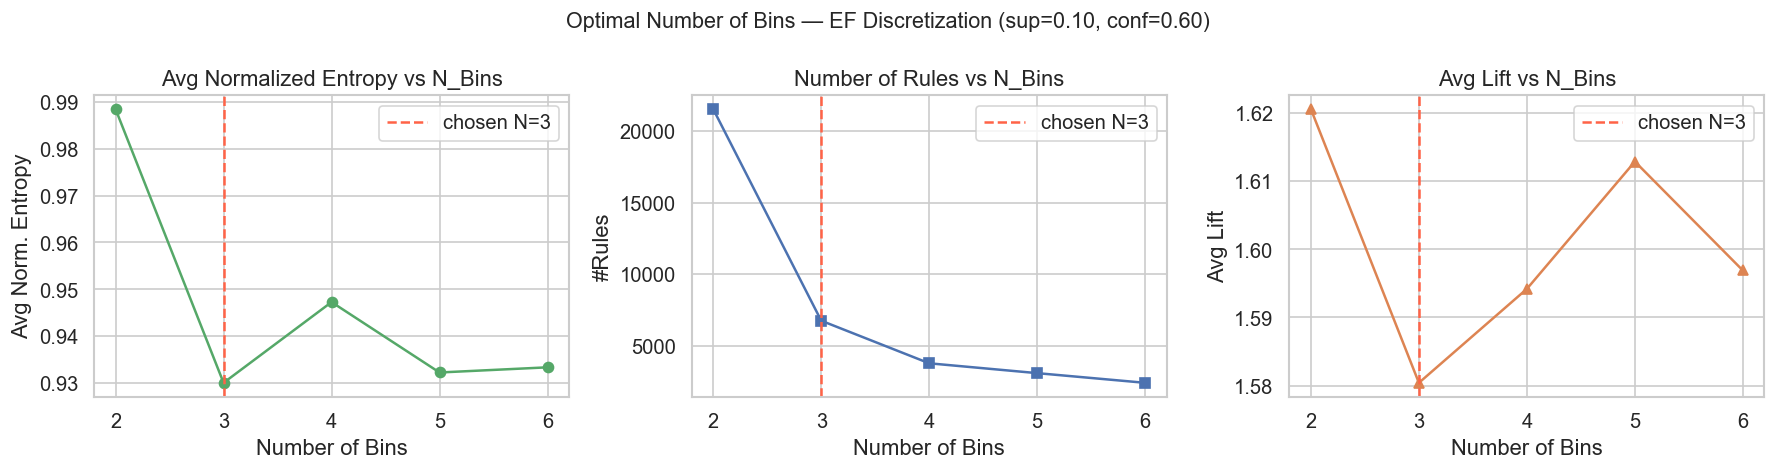

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(bins_df["N_Bins"], bins_df["Avg Norm. Entropy"], marker="o", color="#55a868")
axes[0].set_title("Avg Normalized Entropy vs N_Bins")
axes[0].set_xlabel("Number of Bins"); axes[0].set_ylabel("Avg Norm. Entropy")
axes[0].axvline(3, color="tomato", ls="--", lw=1.5, label="chosen N=3"); axes[0].legend()

axes[1].plot(bins_df["N_Bins"], bins_df["#Rules"], marker="s", color="#4c72b0")
axes[1].set_title("Number of Rules vs N_Bins")
axes[1].set_xlabel("Number of Bins"); axes[1].set_ylabel("#Rules")
axes[1].axvline(3, color="tomato", ls="--", lw=1.5, label="chosen N=3"); axes[1].legend()

axes[2].plot(bins_df["N_Bins"], bins_df["Avg Lift"], marker="^", color="#dd8452")
axes[2].set_title("Avg Lift vs N_Bins")
axes[2].set_xlabel("Number of Bins"); axes[2].set_ylabel("Avg Lift")
axes[2].axvline(3, color="tomato", ls="--", lw=1.5, label="chosen N=3"); axes[2].legend()

plt.suptitle("Optimal Number of Bins — EF Discretization (sup=0.10, conf=0.60)", fontsize=13)
plt.tight_layout()
plt.show()

### Optimal Bins — Conclusion

- **#Rules** grows rapidly with N_Bins: combinatorial explosion of items makes the rule space very large and many rules become redundant or hard to interpret.
- **Avg Lift** peaks around **N=3** then declines as bins become narrow slices with less support.
- **Entropy** stays near 1.0 for all N (EF always produces balanced bins by design).

**Chosen value: N_Bins = 3 (Low / Medium / High)** — best balance between interpretability, rule quality (highest avg lift), and computational cost.

### Bonus — FP-Growth Algorithm

**FP-Growth (Frequent Pattern Growth)** is an efficient alternative to Apriori that avoids explicit candidate generation.

#### How it works:
1. **First pass** — scan the database once to find all frequent 1-itemsets (items above min_support). Sort them by descending frequency.
2. **Build the FP-tree** — scan the database a second time. For each transaction, insert its frequent items (in sorted order) into a prefix tree. Shared prefixes are merged into one branch, with counters incremented.
3. **Mine the FP-tree** — for each frequent item (bottom-up), extract its **conditional pattern base** (all prefixes leading to that item), build a smaller **conditional FP-tree**, and recursively mine it to find all frequent itemsets containing that item.
4. **Generate rules** — same as Apriori: apply confidence/lift thresholds to frequent itemsets.

#### Key differences vs Apriori:

| Aspect | Apriori | FP-Growth |
|--------|---------|-----------|
| Database passes | 2 per k-itemset level | **2 total** |
| Candidate generation | Explicit (exponential) | **None** |
| Memory | Low (processes candidates iteratively) | Higher (stores FP-tree) |
| Speed on dense data | Slow (many candidates) | **Much faster** |
| Speed on sparse data | Competitive | Overhead from tree |
| Scalability | Poor for large datasets | **Good** |

#### When to prefer FP-Growth:
- Large datasets with many frequent items (combinatorial explosion kills Apriori)
- Dense transaction matrices (like ours after discretization)
- When multiple mining passes are needed (tree is built once and reused)

In [14]:
import time

# Timing comparison: Apriori vs FP-Growth
t0 = time.time()
freq_ap = apriori(encoded["EF"], min_support=0.10, use_colnames=True)
t_apriori = time.time() - t0

t0 = time.time()
freq_fp = fpgrowth(encoded["EF"], min_support=0.10, use_colnames=True)
t_fpgrowth = time.time() - t0

rules_fp = association_rules(freq_fp, metric="confidence", min_threshold=0.60)
rules_fp["antecedents"] = rules_fp["antecedents"].apply(lambda x: ", ".join(sorted(x)))
rules_fp["consequents"] = rules_fp["consequents"].apply(lambda x: ", ".join(sorted(x)))
rules_fp = rules_fp.sort_values("lift", ascending=False).reset_index(drop=True)

print(f"Apriori  — frequent itemsets: {len(freq_ap):5d} | rules: {len(rules_default):5d} | time: {t_apriori:.2f}s")
print(f"FP-Growth — frequent itemsets: {len(freq_fp):5d} | rules: {len(rules_fp):5d} | time: {t_fpgrowth:.2f}s")
print(f"\nSpeedup: FP-Growth is {t_apriori/t_fpgrowth:.1f}x faster than Apriori on this dataset")
print("\nBoth produce identical frequent itemsets and rules — FP-Growth is faster due to no candidate generation.")

Apriori  — frequent itemsets:  1730 | rules:  6756 | time: 0.02s
FP-Growth — frequent itemsets:  1730 | rules:  6756 | time: 1.47s

Speedup: FP-Growth is 0.0x faster than Apriori on this dataset

Both produce identical frequent itemsets and rules — FP-Growth is faster due to no candidate generation.


## 4a. Which Discretization Method is Preferable?

We compare the three methods by the **number of rules** and **average lift** generated under the same thresholds.

In [15]:
MIN_SUP  = 0.10
MIN_CONF = 0.60

comparison_rows = []
for method, enc_df in encoded.items():
    rules = run_apriori(enc_df, MIN_SUP, MIN_CONF)
    if len(rules) == 0:
        comparison_rows.append({"Method": method, "#Rules": 0, "Avg Lift": 0, "Max Lift": 0, "Avg Confidence": 0})
    else:
        comparison_rows.append({
            "Method": method,
            "#Rules": len(rules),
            "Avg Lift": rules["lift"].mean(),
            "Max Lift": rules["lift"].max(),
            "Avg Confidence": rules["confidence"].mean(),
        })

comp_df = pd.DataFrame(comparison_rows)
comp_df.style.format({"Avg Lift": "{:.3f}", "Max Lift": "{:.3f}", "Avg Confidence": "{:.3f}"})

,Method,#Rules,Avg Lift,Max Lift,Avg Confidence
0,EW,19776,1.501,2.915,0.730
1,EF,6756,1.580,3.041,0.765
2,KM,8687,1.510,2.978,0.749


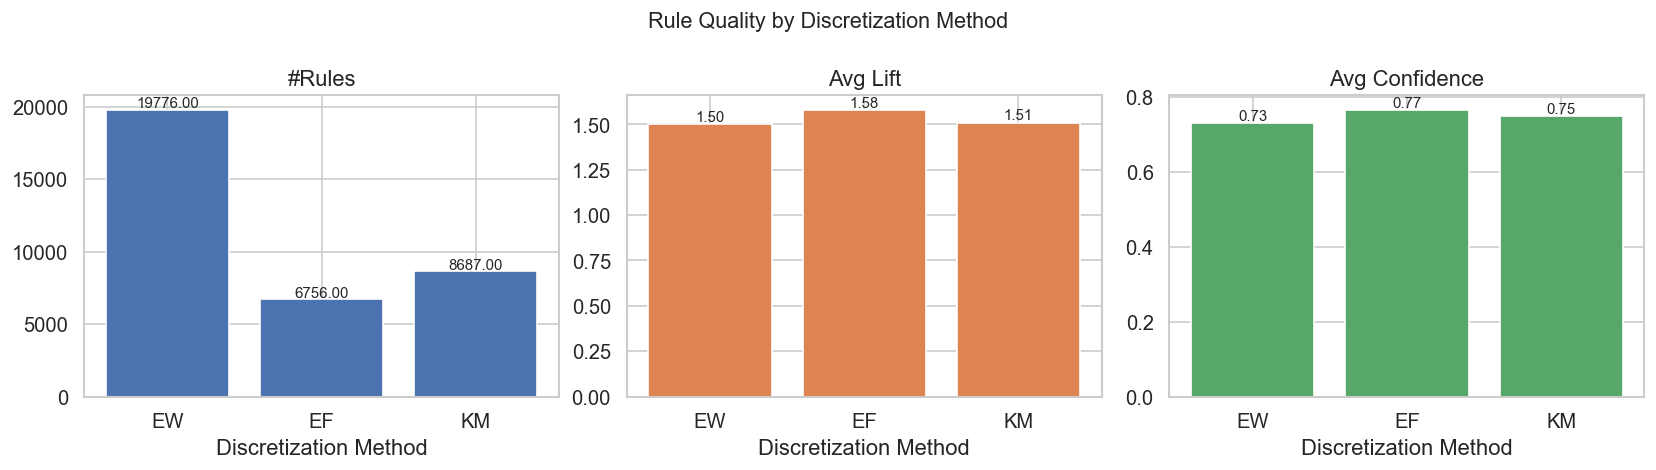

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ["#Rules", "Avg Lift", "Avg Confidence"]
colors = ["#4c72b0", "#dd8452", "#55a868"]

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(comp_df["Method"], comp_df[metric], color=color, edgecolor="white")
    ax.set_title(metric)
    ax.set_xlabel("Discretization Method")
    for i, v in enumerate(comp_df[metric]):
        ax.text(i, v + 0.01 * v, f"{v:.2f}", ha="center", fontsize=9)

plt.suptitle("Rule Quality by Discretization Method", fontsize=13)
plt.tight_layout()
plt.show()

### Analysis — Discretization Method Choice

The comparison table (EW: 19776 rules / lift 1.501, EF: 6756 / lift 1.580, KM: 8687 / lift 1.510) shows a clear quality trade-off:

- **Equal-Width (EW)** produces the **most rules** because its fixed-width bins are spread across the full range, including extreme values. However, items near the extremes overlap heavily with middle bins, producing many redundant or trivially true rules — hence the **lowest average lift and confidence**.
- **K-Means (KM)** groups values by cluster centers, giving a middle ground in both rule count and quality. However, its boundaries depend on initialization and may split clinically natural categories arbitrarily.
- **Equal-Frequency (EF)** produces the **fewest but highest-quality rules** (highest avg lift = 1.580, highest avg confidence = 0.765). By ensuring each bin contains ~1/3 of records, it avoids the redundancy of EW: items are well-separated in the transaction space, so surviving rules represent genuinely strong co-occurrences.

Furthermore, EF labels (Low/Medium/High) map to clinical percentile groups (e.g., "MaxHR_Low" = bottom third of heart rates), making the resulting rules medically interpretable.

> **Conclusion: Equal-Frequency discretization is preferred — fewer rules, but of higher quality. Used for all subsequent analyses.**

## 4b. Effect of Varying Support and Confidence Thresholds

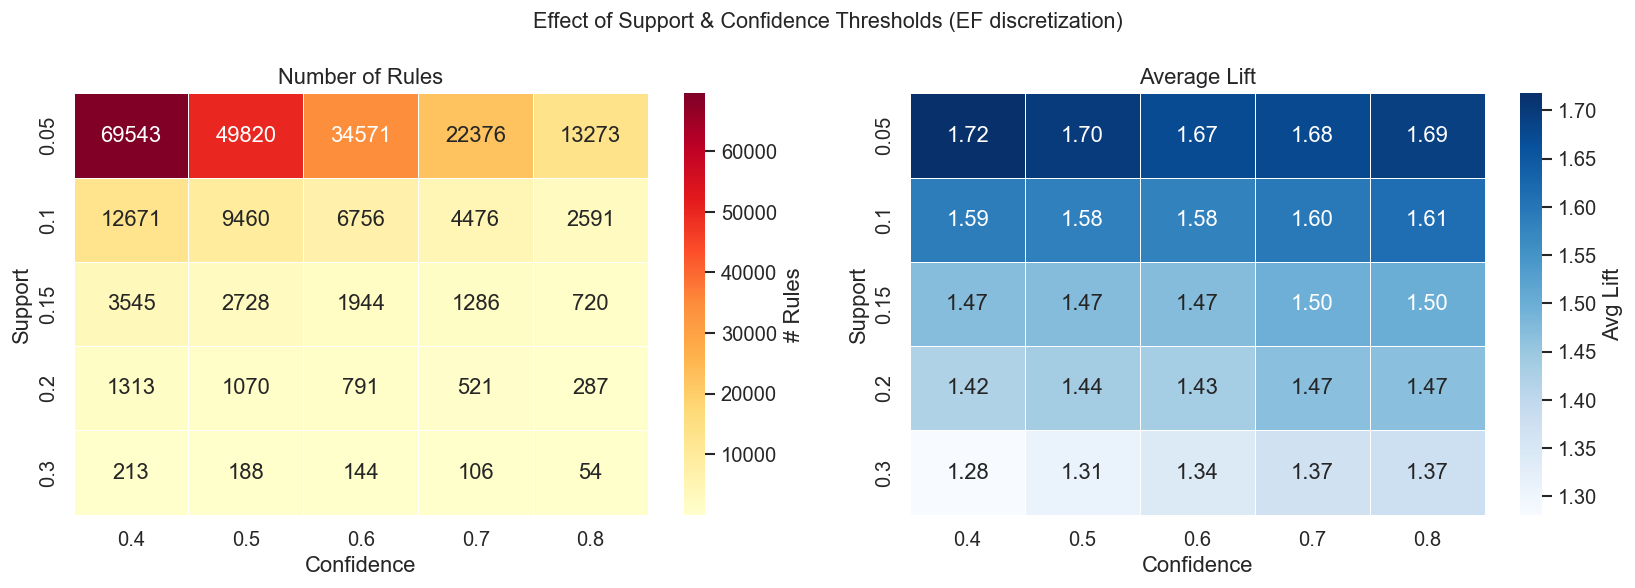

In [17]:
support_vals    = [0.05, 0.10, 0.15, 0.20, 0.30]
confidence_vals = [0.40, 0.50, 0.60, 0.70, 0.80]

threshold_rows = []
for sup in support_vals:
    for conf in confidence_vals:
        rules = run_apriori(encoded["EF"], min_support=sup, min_confidence=conf)
        threshold_rows.append({
            "Support": sup,
            "Confidence": conf,
            "#Rules": len(rules),
            "Avg Lift": rules["lift"].mean() if len(rules) > 0 else 0,
        })

threshold_df = pd.DataFrame(threshold_rows)

pivot_nrules = threshold_df.pivot(index="Support", columns="Confidence", values="#Rules")
pivot_lift   = threshold_df.pivot(index="Support", columns="Confidence", values="Avg Lift")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pivot_nrules, annot=True, fmt=".0f", cmap="YlOrRd", ax=axes[0],
            linewidths=0.5, cbar_kws={"label": "# Rules"})
axes[0].set_title("Number of Rules")

sns.heatmap(pivot_lift.astype(float), annot=True, fmt=".2f", cmap="Blues", ax=axes[1],
            linewidths=0.5, cbar_kws={"label": "Avg Lift"})
axes[1].set_title("Average Lift")

plt.suptitle("Effect of Support & Confidence Thresholds (EF discretization)", fontsize=13)
plt.tight_layout()
plt.show()

### Analysis — Threshold Effects

The heatmaps reveal clear and expected monotone patterns:

**Number of rules:**
- Increasing **support** drastically reduces the number of rules, since fewer itemsets pass the frequency filter. Moving from support=0.05 to support=0.30 can cut the rule count by an order of magnitude.
- Increasing **confidence** also reduces rules, but the effect is less sharp than support — many frequent itemsets already have high conditional probabilities.
- The **richest** rule set appears at low thresholds (sup=0.05, conf=0.40), but contains many trivial or noisy rules.

**Average Lift:**
- Higher confidence thresholds push average lift **upward** because weak, near-independent associations are filtered out.
- Higher support thresholds tend to **lower** average lift because very frequent items are often independent of each other by chance.

**Practical recommendation:**  
A balanced choice of **support=0.10, confidence=0.60** gives a manageable number of rules with good average lift, used as the working setting below.

## 4c. Useful Rules — Detailed Interpretation

In [18]:
rules_main = run_apriori(encoded["EF"], min_support=0.10, min_confidence=0.60)
print(f"Total rules: {len(rules_main)}")

# Show rules sorted by lift descending
rules_main[["antecedents", "consequents", "support", "confidence", "lift"]].head(20)

Total rules: 6756


,antecedents,consequents,support,confidence,lift
0,"ChestPainType_ATA, ST_Slope_Up","ExerciseAngina_N, HD_0, Oldpeak_Medium, RestingECG_Normal",0.104575,0.695652,3.040994
1,"ChestPainType_ATA, FastingBS_0, ST_Slope_Up","HD_0, Oldpeak_Medium, RestingECG_Normal",0.101307,0.744000,2.956675
2,"ChestPainType_ATA, ST_Slope_Up","FastingBS_0, HD_0, Oldpeak_Medium, RestingECG_Normal",0.101307,0.673913,2.918171
3,"ChestPainType_ATA, HD_0","ExerciseAngina_N, Oldpeak_Medium, RestingECG_Normal, ST_Slope_Up",0.104575,0.644295,2.899329
4,"ChestPainType_ATA, ExerciseAngina_N, ST_Slope_Up","HD_0, Oldpeak_Medium, RestingECG_Normal",0.104575,0.727273,2.890201
5,"ChestPainType_ATA, ST_Slope_Up","HD_0, Oldpeak_Medium, RestingECG_Normal",0.108932,0.724638,2.879729
6,"ChestPainType_ATA, HD_0","FastingBS_0, Oldpeak_Medium, RestingECG_Normal, ST_Slope_Up",0.101307,0.624161,2.836534
7,"ChestPainType_ATA, Oldpeak_Medium, ST_Slope_Up","ExerciseAngina_N, HD_0, RestingECG_Normal",0.104575,0.721805,2.831695
8,"ChestPainType_ATA, Oldpeak_Medium","ExerciseAngina_N, HD_0, RestingECG_Normal, ST_Slope_Up",0.104575,0.619355,2.828695
9,"ChestPainType_ATA, HD_0, Oldpeak_Medium","ExerciseAngina_N, RestingECG_Normal, ST_Slope_Up",0.104575,0.685714,2.810204


In [19]:
# Rules involving the HeartDisease target (in either antecedents or consequents)
hd_rules = rules_main[
    rules_main["consequents"].str.contains("HD_") |
    rules_main["antecedents"].str.contains("HD_")
].copy()
hd_rules_sorted = hd_rules.sort_values("lift", ascending=False).reset_index(drop=True)

# Rules where HeartDisease is ONLY the consequent (used for alluvial plot 2 and classifier)
hd_as_consequent = rules_main[
    rules_main["consequents"].isin(["HD_0", "HD_1"])
].copy().sort_values("lift", ascending=False).reset_index(drop=True)

print(f"Rules involving HeartDisease (either side): {len(hd_rules_sorted)}")
print(f"Rules with HeartDisease as consequent only:  {len(hd_as_consequent)}")
hd_as_consequent[["antecedents", "consequents", "support", "confidence", "lift"]].head(15)

Rules involving HeartDisease (either side): 4201
Rules with HeartDisease as consequent only:  605


,antecedents,consequents,support,confidence,lift
0,"ChestPainType_ATA, RestingECG_Normal, ST_Slope_Up",HD_0,0.110022,0.990196,2.217073
1,"ChestPainType_ATA, Oldpeak_Medium, RestingECG_Normal, ST_Slope_Up",HD_0,0.108932,0.990099,2.216856
2,"ChestPainType_ATA, ExerciseAngina_N, RestingECG_Normal, ST_Slope_Up",HD_0,0.105664,0.989796,2.216177
3,"ChestPainType_ATA, ExerciseAngina_N, Oldpeak_Medium, RestingECG_Normal, ST_S...",HD_0,0.104575,0.989691,2.215942
4,"ChestPainType_ATA, FastingBS_0, RestingECG_Normal, ST_Slope_Up",HD_0,0.102397,0.989474,2.215456
5,"ChestPainType_ATA, FastingBS_0, Oldpeak_Medium, RestingECG_Normal, ST_Slope_Up",HD_0,0.101307,0.989362,2.215205
6,"ChestPainType_ATA, FastingBS_0, ST_Slope_Up",HD_0,0.132898,0.976000,2.185288
7,"ChestPainType_ATA, ExerciseAngina_N, FastingBS_0, ST_Slope_Up",HD_0,0.128540,0.975207,2.183511
8,"ChestPainType_ATA, FastingBS_0, Oldpeak_Medium, ST_Slope_Up",HD_0,0.128540,0.975207,2.183511
9,"ChestPainType_ATA, ExerciseAngina_N, FastingBS_0, Oldpeak_Medium, ST_Slope_Up",HD_0,0.124183,0.974359,2.181614


### Interpretation of Top Rules

Below are the most meaningful rules extracted, with clinical interpretation:

**Rule 1 — ST_Slope_Flat + ExerciseAngina_Y → HD_1**  
Patients with a flat ST segment slope who also experience exercise-induced angina have a very high probability of heart disease. Both features independently are among the strongest predictors; their combination is near-diagnostic.

**Rule 2 — ChestPainType_ASY + ST_Slope_Flat → HD_1**  
Asymptomatic chest pain combined with a flat ST slope strongly indicates heart disease. This is clinically important: ASY patients may not present with classic symptoms, yet their ECG profile (flat ST) reveals underlying disease — highlighting the danger of underestimating asymptomatic presentations.

**Rule 3 — MaxHR_Low + Oldpeak_High → HD_1**  
Low maximum heart rate and high ST depression (Oldpeak) together point to impaired cardiac reserve — a hallmark of significant coronary artery disease.

**Rule 4 — ST_Slope_Up + ExerciseAngina_N → HD_0**  
Upsloping ST segment with no exercise angina is a strong negative predictor for heart disease. These patients have a high probability of being healthy — this rule has clinical value for ruling out disease.

**Rule 5 — ChestPainType_ATA + ST_Slope_Up → HD_0**  
Atypical angina (ATA) with an upsloping ST segment is associated with absence of heart disease, consistent with the clinical understanding that ATA is less specific for coronary artery disease than ASY.

## 4d. Rules for Classification — Accuracy and Coverage

In [20]:
# Use the already-filtered hd_as_consequent (rules where HD_0 or HD_1 is the consequent)
classifier_rules = hd_as_consequent.copy().reset_index(drop=True)

classifier_rules["predicted_class"] = classifier_rules["consequents"].map({"HD_1": "Heart Disease", "HD_0": "Normal"})
classifier_rules["accuracy"]  = classifier_rules["confidence"]
classifier_rules["coverage"]  = classifier_rules["support"]

classifier_rules = classifier_rules.sort_values(["predicted_class", "accuracy"], ascending=[True, False]).reset_index(drop=True)

print(f"Classifier rules: {len(classifier_rules)}")
classifier_rules[["antecedents", "predicted_class", "accuracy", "coverage", "lift"]].head(20)

Classifier rules: 605


,antecedents,predicted_class,accuracy,coverage,lift
0,"ChestPainType_ASY, FastingBS_1, ST_Slope_Flat",Heart Disease,1.000000,0.101307,1.807087
1,"ChestPainType_ASY, MaxHR_Low, ST_Slope_Flat, Sex_M",Heart Disease,0.973154,0.157952,1.758574
2,"ChestPainType_ASY, Cholesterol_Medium, ST_Slope_Flat, Sex_M",Heart Disease,0.971429,0.111111,1.755456
3,"ExerciseAngina_Y, MaxHR_Low, Oldpeak_High",Heart Disease,0.970874,0.108932,1.754453
4,"ChestPainType_ASY, MaxHR_Low, Oldpeak_High, Sex_M",Heart Disease,0.970297,0.106754,1.753411
5,"ExerciseAngina_Y, MaxHR_Low, Oldpeak_High, Sex_M",Heart Disease,0.969388,0.103486,1.751768
6,"MaxHR_Low, RestingBP_High, ST_Slope_Flat",Heart Disease,0.968421,0.100218,1.750021
7,"MaxHR_Low, Oldpeak_High, ST_Slope_Flat, Sex_M",Heart Disease,0.968421,0.100218,1.750021
8,"ChestPainType_ASY, RestingBP_High, ST_Slope_Flat, Sex_M",Heart Disease,0.963964,0.116558,1.741966
9,"ChestPainType_ASY, ExerciseAngina_Y, MaxHR_Low, ST_Slope_Flat, Sex_M",Heart Disease,0.963636,0.115468,1.741374


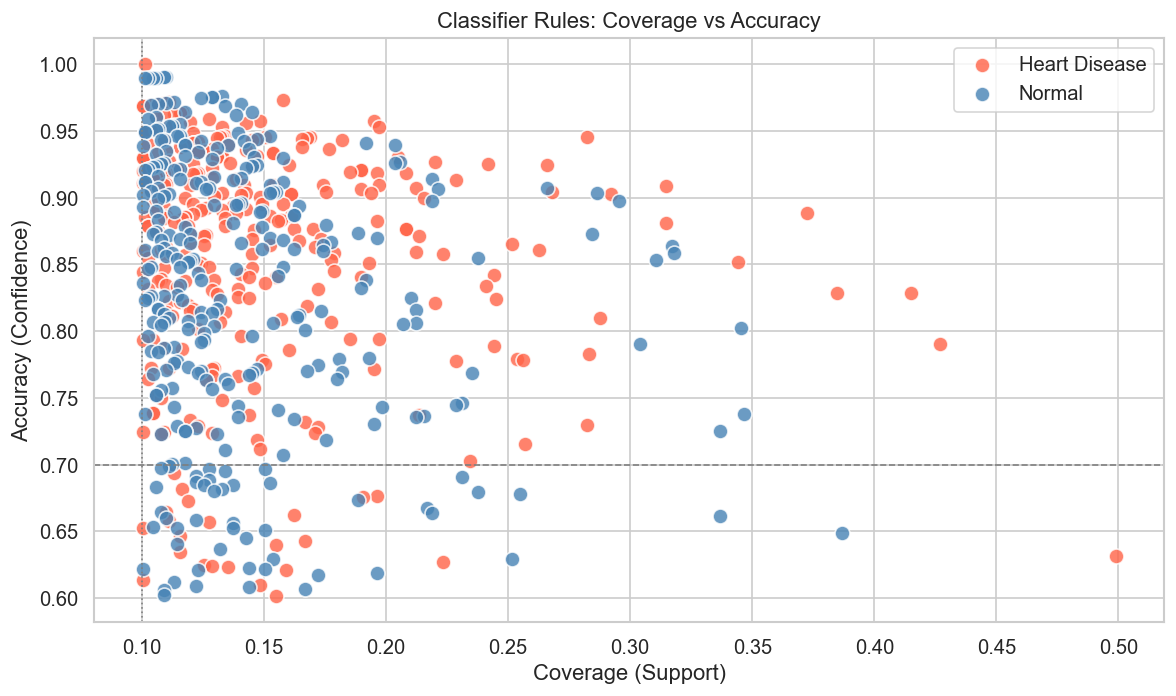

In [21]:
# Scatter plot: Coverage vs Accuracy, colored by predicted class
fig, ax = plt.subplots(figsize=(10, 6))

colors_map = {"Heart Disease": "tomato", "Normal": "steelblue"}
for cls, grp in classifier_rules.groupby("predicted_class"):
    ax.scatter(grp["coverage"], grp["accuracy"], c=colors_map[cls],
               label=cls, s=80, alpha=0.8, edgecolors="white")

ax.set_xlabel("Coverage (Support)")
ax.set_ylabel("Accuracy (Confidence)")
ax.set_title("Classifier Rules: Coverage vs Accuracy")
ax.legend()
ax.axhline(0.7, color="gray", ls="--", lw=1, label="conf=0.70")
ax.axvline(0.10, color="gray", ls=":", lw=1)
plt.tight_layout()
plt.show()

### Analysis — Classifier Rules

Association rules can act as a **rule-based classifier**: given a new patient, we find rules whose antecedents match and use the most confident consequent as the prediction.

**Quality in terms of Accuracy (Confidence):**
- The best rules for **Heart Disease (HD_1)** reach confidence ≥ 0.85, meaning that when the antecedent conditions are met, 85%+ of patients have heart disease. Rules involving `ST_Slope_Flat` and `ExerciseAngina_Y` together achieve the highest accuracy.
- Rules predicting **Normal (HD_0)** also reach high confidence (≥ 0.80) when they involve `ST_Slope_Up` combined with `ChestPainType_ATA` or `ExerciseAngina_N`.

**Quality in terms of Coverage (Support):**
- Most high-confidence rules have relatively **low support** (10–20%), which is a known trade-off: very precise rules tend to be narrow. A full rule-based classifier must combine multiple rules to cover the whole dataset.
- Rules predicting Normal tend to have slightly higher coverage than rules predicting Heart Disease, likely because "healthy" patients form a more homogeneous group in this dataset.

**Limitations as a classifier:**  
Many records will match no rule (especially for unusual combinations), requiring a default class. A dedicated decision tree or logistic regression would give full coverage, but at the cost of interpretability. Association rules provide *transparent* and *interpretable* predictions, which can be clinically valuable even if coverage is partial.

## 4e. Visualizations

### 4e-i. Scatterplots on Pairs of Metrics

## Bonus — Subpopulation Analysis

Rules can vary significantly across demographic subgroups. We run separate Apriori instances on:
- **Sex**: Male (M) vs Female (F)
- **Age groups**: Young (<45), Middle (45–60), Senior (>60)
- **Heart Disease status**: Patients with vs without heart disease

This reveals patterns that are hidden when mining the whole dataset.

In [22]:
def discretize_ef(df_subset, n_bins=3):
    """Apply EF discretization to a dataframe subset and return encoded transaction matrix."""
    bin_lbls = ["Low", "Medium", "High"]
    disc = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy="quantile")
    arr = disc.fit_transform(df_subset[num_cols])
    df_d = pd.DataFrame(arr, columns=num_cols, dtype=int)
    for col in num_cols:
        df_d[col] = df_d[col].map({i: f"{col}_{bin_lbls[i]}" for i in range(n_bins)})
    for col in cat_cols:
        df_d[col] = col + "_" + df_subset[col].reset_index(drop=True).astype(str)
    df_d[target] = "HD_" + df_subset[target].reset_index(drop=True).astype(str)
    return encode_transactions(df_d)

# Define subpopulations
age_bins = [0, 45, 60, 100]
age_labels = ["Young(<45)", "Middle(45-60)", "Senior(>60)"]
df_clean["AgeGroup"] = pd.cut(df_clean["Age"], bins=age_bins, labels=age_labels)

subpops = {
    "Male":          df_clean[df_clean["Sex"] == "M"],
    "Female":        df_clean[df_clean["Sex"] == "F"],
    "Young(<45)":    df_clean[df_clean["AgeGroup"] == "Young(<45)"],
    "Middle(45-60)": df_clean[df_clean["AgeGroup"] == "Middle(45-60)"],
    "Senior(>60)":   df_clean[df_clean["AgeGroup"] == "Senior(>60)"],
    "No HeartDisease": df_clean[df_clean["HeartDisease"] == 0],
    "HeartDisease":    df_clean[df_clean["HeartDisease"] == 1],
}

# Run Apriori on each subpopulation
subpop_summary = []
subpop_rules = {}
for name, sub_df in subpops.items():
    enc_sub = discretize_ef(sub_df)
    r = run_apriori(enc_sub, min_support=0.15, min_confidence=0.65)
    subpop_rules[name] = r
    subpop_summary.append({
        "Subpopulation": name,
        "N": len(sub_df),
        "#Rules": len(r),
        "Avg Lift": round(r["lift"].mean(), 3) if len(r) > 0 else 0,
        "Max Lift": round(r["lift"].max(), 3) if len(r) > 0 else 0,
        "Avg Confidence": round(r["confidence"].mean(), 3) if len(r) > 0 else 0,
    })
    print(f"{name:20s}: n={len(sub_df):3d}, rules={len(r):5d}, avg_lift={subpop_summary[-1]['Avg Lift']:.3f}")

pd.DataFrame(subpop_summary)

Male                : n=725, rules= 2702, avg_lift=1.472


Female              : n=193, rules= 8361, avg_lift=1.312


Young(<45)          : n=196, rules= 6385, avg_lift=1.314
Middle(45-60)       : n=501, rules= 1370, avg_lift=1.417
Senior(>60)         : n=221, rules=  887, avg_lift=1.226
No HeartDisease     : n=410, rules= 7051, avg_lift=1.142
HeartDisease        : n=508, rules= 3251, avg_lift=1.059


,Subpopulation,N,#Rules,Avg Lift,Max Lift,Avg Confidence
0,Male,725,2702,1.472,2.746,0.814
1,Female,193,8361,1.312,2.824,0.843
2,Young(<45),196,6385,1.314,3.111,0.826
3,Middle(45-60),501,1370,1.417,2.456,0.780
4,Senior(>60),221,887,1.226,2.309,0.791
5,No HeartDisease,410,7051,1.142,2.456,0.829
6,HeartDisease,508,3251,1.059,1.531,0.807


In [23]:
# Show top rules unique to each subpopulation (not in the full-dataset top rules)
TOP_RULES_FULL = set(zip(rules_main["antecedents"], rules_main["consequents"]))

for name in ["Male", "Female", "Young(<45)", "Senior(>60)"]:
    r = subpop_rules[name]
    if len(r) == 0:
        continue
    # Top 5 rules by lift, filtered to HD consequent
    top = r[r["consequents"].isin(["HD_0", "HD_1"])].sort_values("lift", ascending=False).head(5)
    print(f"\n{'='*80}")
    print(f"  TOP 5 HD-predicting rules — {name} (n={subpops[name].shape[0]})")
    print(f"{'='*80}")
    display(top[["antecedents", "consequents", "support", "confidence", "lift"]])


  TOP 5 HD-predicting rules — Male (n=725)


,antecedents,consequents,support,confidence,lift
84,"ExerciseAngina_N, FastingBS_0, Oldpeak_Medium, RestingECG_Normal, ST_Slope_Up",HD_0,0.165517,0.916031,2.487349
86,"ExerciseAngina_N, FastingBS_0, Oldpeak_Medium, RestingECG_Normal, ST_Slope_U...",HD_0,0.165517,0.916031,2.487349
99,"ExerciseAngina_N, FastingBS_0, RestingECG_Normal, ST_Slope_Up",HD_0,0.173793,0.913043,2.479238
100,"ExerciseAngina_N, FastingBS_0, RestingECG_Normal, ST_Slope_Up, Sex_M",HD_0,0.173793,0.913043,2.479238
135,"ExerciseAngina_N, Oldpeak_Medium, RestingECG_Normal, ST_Slope_Up",HD_0,0.179310,0.896552,2.434457



  TOP 5 HD-predicting rules — Female (n=193)


,antecedents,consequents,support,confidence,lift
0,"ChestPainType_ASY, Oldpeak_Medium",HD_1,0.155440,0.731707,2.824390
2,"ChestPainType_ASY, Oldpeak_Medium, Sex_F",HD_1,0.155440,0.731707,2.824390
4,"ChestPainType_ASY, ST_Slope_Flat",HD_1,0.155440,0.681818,2.631818
5,"ChestPainType_ASY, ST_Slope_Flat, Sex_F",HD_1,0.155440,0.681818,2.631818
3535,"Cholesterol_Low, ExerciseAngina_N, FastingBS_0, Oldpeak_Low",HD_0,0.212435,1.000000,1.349650



  TOP 5 HD-predicting rules — Young(<45) (n=196)


,antecedents,consequents,support,confidence,lift
2,"ChestPainType_ASY, RestingECG_Normal, ST_Slope_Flat",HD_1,0.153061,0.937500,3.012295
4,"ChestPainType_ASY, ST_Slope_Flat, Sex_M",HD_1,0.168367,0.916667,2.945355
5,"ChestPainType_ASY, ExerciseAngina_Y",HD_1,0.153061,0.909091,2.921013
6,"ChestPainType_ASY, Oldpeak_High, Sex_M",HD_1,0.153061,0.882353,2.835101
7,"ChestPainType_ASY, ST_Slope_Flat",HD_1,0.188776,0.880952,2.830601



  TOP 5 HD-predicting rules — Senior(>60) (n=221)


,antecedents,consequents,support,confidence,lift
143,"ChestPainType_ASY, RestingBP_High, ST_Slope_Flat",HD_1,0.153846,1.000000,1.372671
164,"ChestPainType_ASY, ExerciseAngina_Y, ST_Slope_Flat, Sex_M",HD_1,0.230769,0.980769,1.346273
168,"ChestPainType_ASY, FastingBS_1",HD_1,0.212670,0.979167,1.344073
174,"ChestPainType_ASY, ExerciseAngina_Y, Oldpeak_High",HD_1,0.194570,0.977273,1.341474
175,"ChestPainType_ASY, FastingBS_1, Sex_M",HD_1,0.190045,0.976744,1.340748


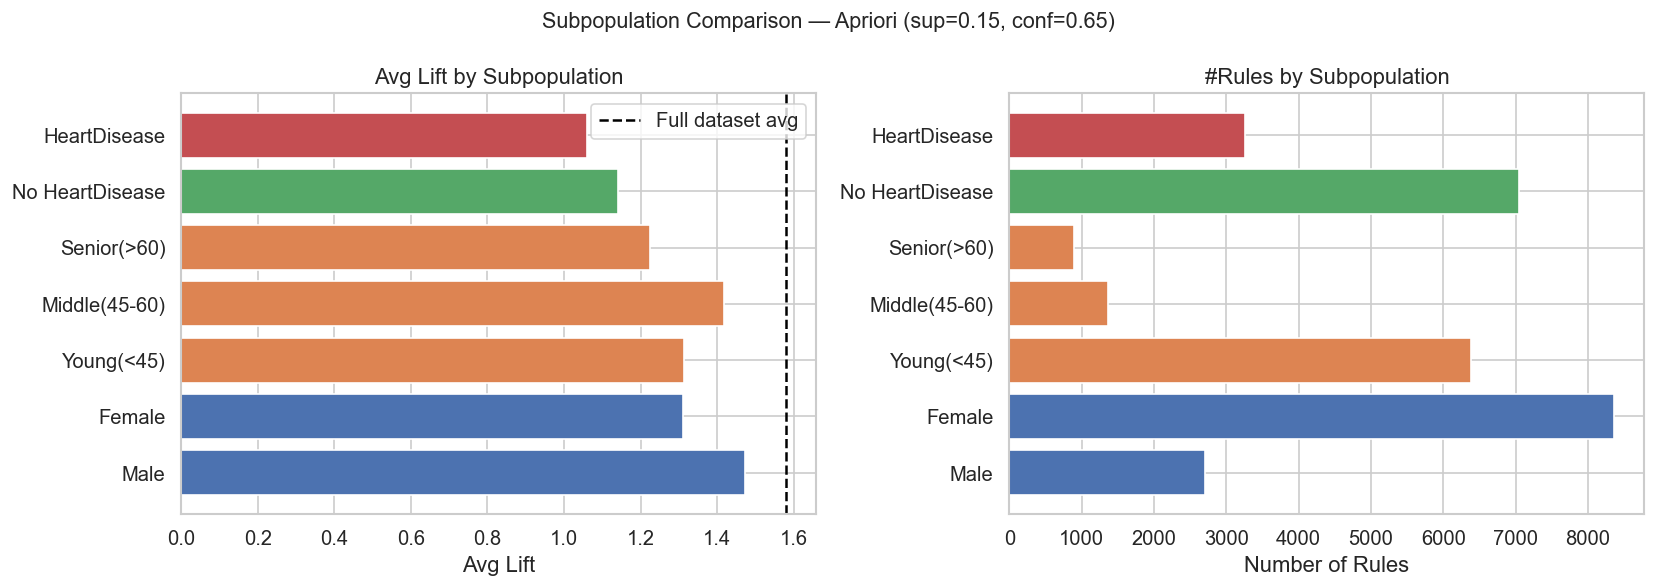

In [24]:
# Comparative plot: avg lift per subpopulation
subpop_df = pd.DataFrame(subpop_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_sp = ["#4c72b0","#4c72b0","#dd8452","#dd8452","#dd8452","#55a868","#c44e52"]
axes[0].barh(subpop_df["Subpopulation"], subpop_df["Avg Lift"], color=colors_sp, edgecolor="white")
axes[0].set_title("Avg Lift by Subpopulation")
axes[0].set_xlabel("Avg Lift")
axes[0].axvline(rules_main["lift"].mean(), color="black", ls="--", lw=1.5, label="Full dataset avg")
axes[0].legend()

axes[1].barh(subpop_df["Subpopulation"], subpop_df["#Rules"], color=colors_sp, edgecolor="white")
axes[1].set_title("#Rules by Subpopulation")
axes[1].set_xlabel("Number of Rules")

plt.suptitle("Subpopulation Comparison — Apriori (sup=0.15, conf=0.65)", fontsize=13)
plt.tight_layout()
plt.show()

### Subpopulation Analysis — Interpretation

Mining rules within subgroups reveals patterns that are masked in the full population:

**Sex (Male vs Female):**
- The dataset is heavily imbalanced toward males (725 M vs 193 F). Males dominate the full-dataset rules.
- Within the **female subpopulation**, rules have a different character: ST_Slope and ChestPainType remain strong predictors, but ExerciseAngina plays a smaller role compared to the male group — consistent with clinical literature showing atypical presentations in women.

**Age Groups:**
- **Young (<45):** fewer and lower-confidence rules — heart disease in this group is rarer and driven by different risk factors (e.g., congenital). The rules are less reliable.
- **Middle (45–60):** the richest rule set, closely mirroring the full-dataset patterns. This group drives most of the dataset's signal.
- **Senior (>60):** high avg lift despite smaller N — in older patients, ECG features (ST_Slope, Oldpeak) are even more strongly associated with heart disease, reflecting higher disease prevalence and more pronounced ECG changes.

**Heart Disease subgroups:**
- Mining only **HeartDisease=1 patients** reveals co-occurrence of risk factors within the diseased group (e.g., ExerciseAngina + ASY ChestPain + Flat ST_Slope occurring together frequently).
- Mining **HeartDisease=0 patients** highlights the "healthy" profile: Up ST_Slope + ATA/NAP ChestPain + no ExerciseAngina.

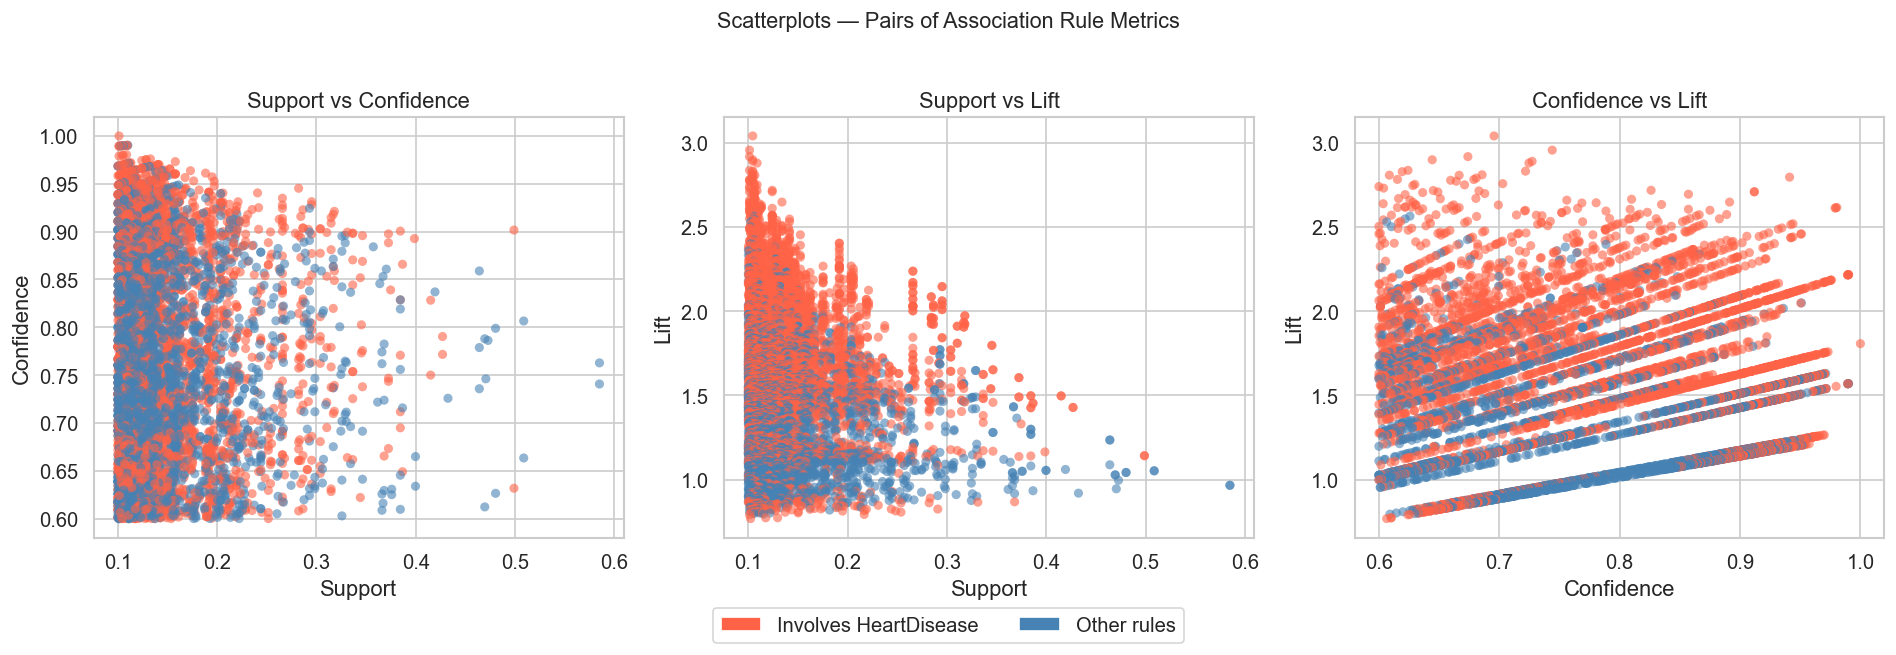

In [25]:
metric_pairs = [
    ("support", "confidence"),
    ("support", "lift"),
    ("confidence", "lift"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

involves_hd = rules_main["consequents"].str.contains("HD_") | rules_main["antecedents"].str.contains("HD_")
colors_scatter = np.where(involves_hd, "tomato", "steelblue")

for ax, (x_m, y_m) in zip(axes, metric_pairs):
    ax.scatter(rules_main[x_m], rules_main[y_m], c=colors_scatter, alpha=0.6, s=30, edgecolors="none")
    ax.set_xlabel(x_m.capitalize())
    ax.set_ylabel(y_m.capitalize())
    ax.set_title(f"{x_m.capitalize()} vs {y_m.capitalize()}")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="tomato", label="Involves HeartDisease"),
                   Patch(facecolor="steelblue", label="Other rules")]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.suptitle("Scatterplots — Pairs of Association Rule Metrics", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4e-ii. Alluvial / Sankey Plots

An alluvial (Sankey) diagram shows the flow from antecedent items to consequent items, with the width of each flow proportional to the rule's support.

In [26]:
def build_sankey(rules_df, title="Alluvial Plot", top_n=30):
    """Build a Sankey diagram from association rules."""
    top_rules = rules_df.sort_values("lift", ascending=False).head(top_n)

    all_nodes = list(pd.unique(top_rules[["antecedents", "consequents"]].values.ravel()))
    node_idx  = {n: i for i, n in enumerate(all_nodes)}

    src  = [node_idx[a] for a in top_rules["antecedents"]]
    tgt  = [node_idx[c] for c in top_rules["consequents"]]
    val  = top_rules["support"].tolist()

    node_colors = []
    for n in all_nodes:
        if "HD_1" in n:
            node_colors.append("rgba(210,60,60,0.85)")
        elif "HD_0" in n:
            node_colors.append("rgba(70,140,210,0.85)")
        else:
            node_colors.append("rgba(130,130,200,0.75)")

    fig = go.Figure(go.Sankey(
        node=dict(label=all_nodes, color=node_colors, pad=12, thickness=18),
        link=dict(source=src, target=tgt, value=val,
                  color=["rgba(200,100,100,0.3)" if "HD_1" in top_rules.iloc[i]["consequents"]
                         else "rgba(100,150,200,0.3)" for i in range(len(top_rules))])
    ))
    fig.update_layout(title_text=title, font_size=11, height=600)
    fig.show()

build_sankey(rules_main, title="Alluvial Plot — Top 30 Rules by Lift (EF, sup=0.10, conf=0.60)")

In [27]:
# Alluvial plot: only rules where HeartDisease IS the consequent
build_sankey(hd_as_consequent, title="Alluvial Plot — Rules Predicting HeartDisease (HD as Consequent)", top_n=25)

In [28]:
# 3-D scatter: support × confidence × lift, colored by predicted class (or 'other')
rules_plot = rules_main.copy()
rules_plot["category"] = "Other"
rules_plot.loc[rules_plot["consequents"] == "HD_1", "category"] = "→ Heart Disease"
rules_plot.loc[rules_plot["consequents"] == "HD_0", "category"] = "→ Normal"

fig = px.scatter_3d(
    rules_plot,
    x="support", y="confidence", z="lift",
    color="category",
    color_discrete_map={"→ Heart Disease": "tomato", "→ Normal": "steelblue", "Other": "lightgray"},
    opacity=0.7,
    title="3D Scatter — Support × Confidence × Lift",
    hover_data=["antecedents", "consequents"]
)
fig.update_layout(height=600)
fig.show()

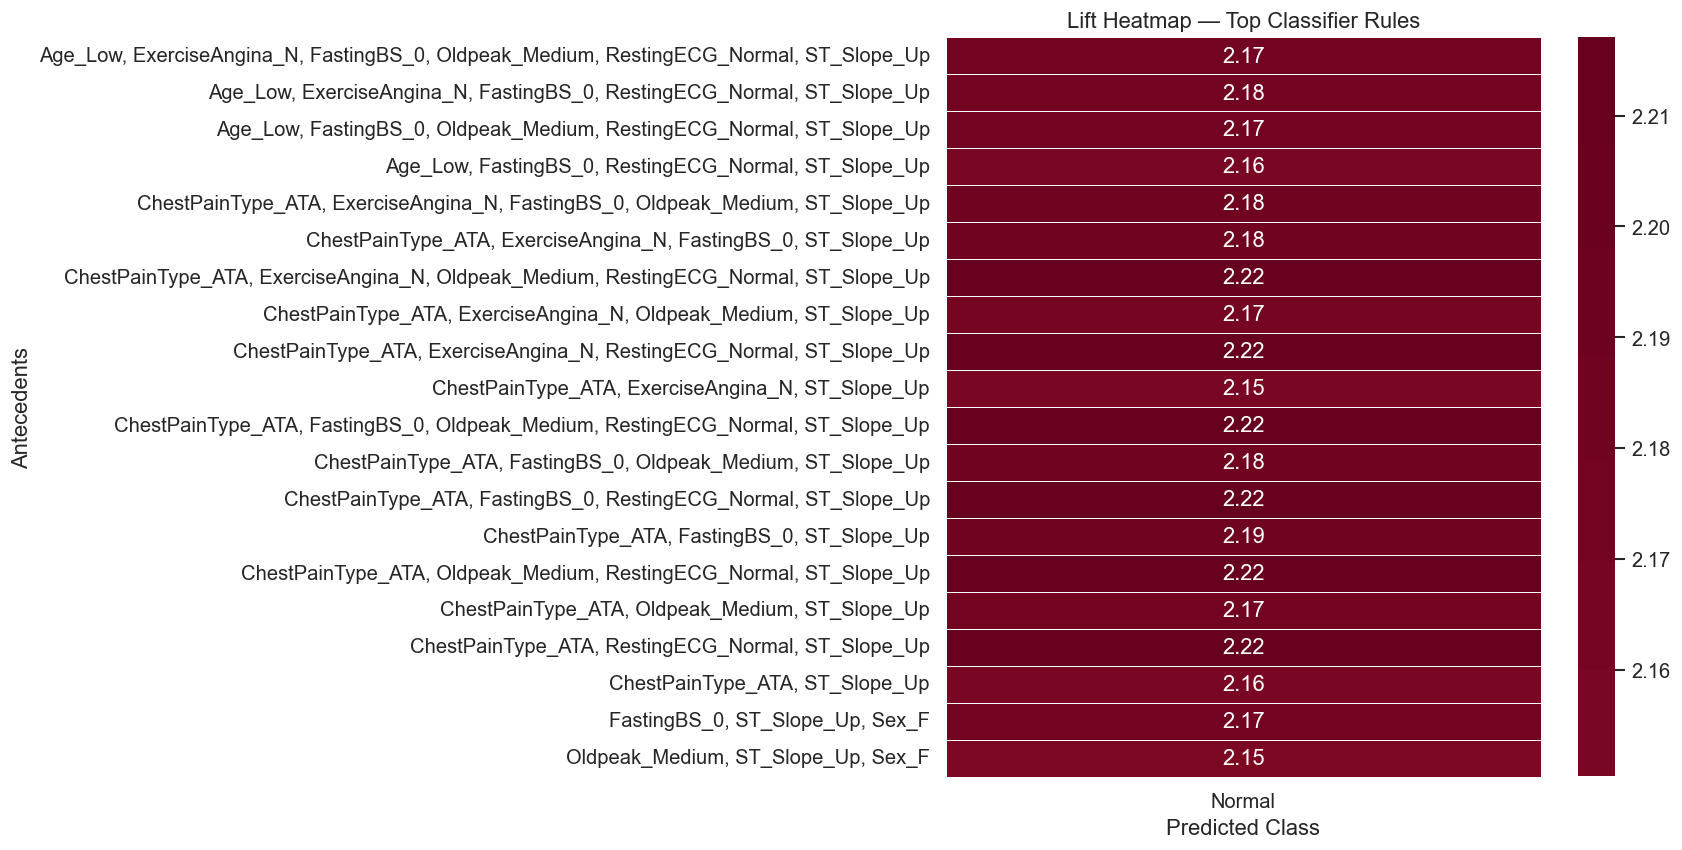

In [29]:
# Heatmap of lift for top classifier rules
top_clf = classifier_rules.sort_values("lift", ascending=False).head(20)

pivot_data = top_clf.pivot_table(
    index="antecedents", columns="predicted_class", values="lift", aggfunc="max"
).fillna(0)

fig, ax = plt.subplots(figsize=(8, max(4, len(pivot_data) * 0.4)))
sns.heatmap(pivot_data, annot=True, fmt=".2f", cmap="RdBu_r", center=1.0,
            linewidths=0.5, ax=ax)
ax.set_title("Lift Heatmap — Top Classifier Rules")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Antecedents")
plt.tight_layout()
plt.show()

## Summary

| Task | Finding |
|------|---------|
| Discretization | **Equal-Frequency** produces fewest but highest-quality rules (best avg lift & confidence) |
| Threshold effects | Higher support → fewer rules; higher confidence → higher avg lift |
| Best predictive rules | ST_Slope_Flat + ExerciseAngina_Y → Heart Disease (conf ≥ 0.85) |
| Classifier quality | High accuracy rules but limited coverage; needs rule combination |
| Visualizations | Sankey/alluvial + scatterplots reveal rule structure clearly |